In [9]:
import scipy.io as sio
import numpy as np
import pandas as pd
import glob
import os
import re
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, hilbert
from scipy.fft import fft, fftfreq

def load_mat_file(filepath, default_rpm=1772):
    data = sio.loadmat(filepath)
    de_key = [k for k in data if 'DE_time' in k][0]
    rpm_keys = [k for k in data if 'RPM' in k]
    signal = data[de_key].flatten()
    if rpm_keys:
        rpm = int(data[rpm_keys[0]][0, 0])
    else:
        rpm = default_rpm  # Normal file doesn't report RPM; assumed same as other load-1 files
    return signal, rpm

def parse_label(filename):
    name = os.path.basename(filename).replace(".mat", "")
    if "Normal" in name:
        return "Normal", None
    match = re.match(r"([A-Za-z]+)(\d+)", name)
    if match:
        return match.group(1), match.group(2)
    return "Unknown", None

In [10]:
data_dir = "../data/raw/cwru"
mat_files = glob.glob(os.path.join(data_dir, "*.mat"))

summary = []
for f in mat_files:
    signal, rpm = load_mat_file(f)
    fault_type, severity = parse_label(f)
    summary.append({
        "file": os.path.basename(f),
        "fault_type": fault_type,
        "severity": severity,
        "rpm": rpm,
        "n_samples": len(signal),
        "duration_sec": len(signal) / 48000
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

                    file fault_type severity   rpm  n_samples  duration_sec
0         B007_1_123.mat          B      007  1772     487384     10.153833
1         B014_1_190.mat          B      014  1772     486224     10.129667
2         B021_1_227.mat          B      021  1774     486804     10.141750
3        IR007_1_110.mat         IR      007  1772     486224     10.129667
4        IR014_1_175.mat         IR      014  1772     489125     10.190104
5        IR021_1_214.mat         IR      021  1774     485063     10.105479
6      OR007_6_1_136.mat         OR      007  1774     486804     10.141750
7      OR014_6_1_202.mat         OR      014  1772     484483     10.093396
8      OR021_6_1_239.mat         OR      021  1771     489125     10.190104
9  Time_Normal_1_098.mat     Normal      NaN  1772     483903     10.081312


In [11]:
def compute_bearing_frequencies(rpm, n_balls=9, d=7.938, D=38.5, theta=0):
    fr = rpm / 60
    ratio = (d / D) * np.cos(np.radians(theta))
    BPFO = (n_balls / 2) * fr * (1 - ratio)
    BPFI = (n_balls / 2) * fr * (1 + ratio)
    BSF  = (D / (2 * d)) * fr * (1 - ratio**2)
    FTF  = (fr / 2) * (1 - ratio)
    return {"BPFO": BPFO, "BPFI": BPFI, "BSF": BSF, "FTF": FTF, "fr": fr}

def envelope_spectrum(signal, fs=48000, band=(2500, 3500)):
    nyq = fs / 2
    b, a = butter(4, [band[0]/nyq, band[1]/nyq], btype='band')
    filtered = filtfilt(b, a, signal)
    envelope = np.abs(hilbert(filtered))
    envelope = envelope - envelope.mean()
    n = len(envelope)
    yf = np.abs(fft(envelope))[:n // 2] / n
    xf = fftfreq(n, 1/fs)[:n // 2]
    return xf, yf

def energy_near_frequency(xf, yf, target_freq, window=3):
    mask = (xf > target_freq - window) & (xf < target_freq + window)
    if not mask.any():
        return 0.0
    return yf[mask].max()

In [12]:
signal, rpm = load_mat_file("../data/raw/cwru/B007_1_123.mat")
freqs = compute_bearing_frequencies(rpm)
xf, yf = envelope_spectrum(signal)

for name in ["BPFO", "BPFI", "BSF"]:
    for harmonic in [1, 2, 3]:
        target = freqs[name] * harmonic
        amp = energy_near_frequency(xf, yf, target)
        print(f"{name} x{harmonic} ({target:.1f} Hz): {amp:.6f}")

BPFO x1 (105.5 Hz): 0.003396
BPFO x2 (211.0 Hz): 0.004748
BPFO x3 (316.5 Hz): 0.003035
BPFI x1 (160.3 Hz): 0.002349
BPFI x2 (320.6 Hz): 0.003035
BPFI x3 (480.9 Hz): 0.002098
BSF x1 (68.6 Hz): 0.003038
BSF x2 (137.2 Hz): 0.002465
BSF x3 (205.7 Hz): 0.001837


In [7]:
data_normal = sio.loadmat("../data/raw/cwru/Time_Normal_1_098.mat")
print([k for k in data_normal.keys() if not k.startswith("__")])

['X098_DE_time', 'X098_FE_time']


In [13]:
def extract_window_features(window, rpm, fs=48000):
    """One window of raw signal -> one row of frequency-domain features."""
    freqs = compute_bearing_frequencies(rpm)
    xf, yf = envelope_spectrum(window, fs=fs)

    features = {}
    for name in ["BPFO", "BPFI", "BSF"]:
        for harmonic in [1, 2, 3]:
            target = freqs[name] * harmonic
            features[f"{name}_x{harmonic}"] = energy_near_frequency(xf, yf, target)

    # A couple of simple time-domain stats too, cheap to add, often genuinely useful alongside frequency features
    features["rms"] = np.sqrt(np.mean(window**2))
    features["kurtosis"] = pd.Series(window).kurtosis()

    return features

def process_file(filepath, window_size=2048):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)

    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features(window, rpm)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        rows.append(feats)
    return rows

all_rows = []
for f in mat_files:
    all_rows.extend(process_file(f))

bearing_df = pd.DataFrame(all_rows)
print(bearing_df.shape)
print(bearing_df["fault_type"].value_counts())
print(bearing_df.head())

(2369, 14)
fault_type
B         711
IR        711
OR        711
Normal    236
Name: count, dtype: int64
   BPFO_x1   BPFO_x2  BPFO_x3  BPFI_x1  BPFI_x2  BPFI_x3    BSF_x1  BSF_x2  \
0      0.0  0.003697      0.0      0.0      0.0      0.0  0.014284     0.0   
1      0.0  0.011968      0.0      0.0      0.0      0.0  0.008986     0.0   
2      0.0  0.016038      0.0      0.0      0.0      0.0  0.002648     0.0   
3      0.0  0.017136      0.0      0.0      0.0      0.0  0.024676     0.0   
4      0.0  0.008595      0.0      0.0      0.0      0.0  0.008025     0.0   

   BSF_x3       rms  kurtosis fault_type severity     source_file  
0     0.0  0.124006 -0.036491          B      007  B007_1_123.mat  
1     0.0  0.134312 -0.075956          B      007  B007_1_123.mat  
2     0.0  0.151008 -0.269128          B      007  B007_1_123.mat  
3     0.0  0.158422  0.141028          B      007  B007_1_123.mat  
4     0.0  0.139922  0.410030          B      007  B007_1_123.mat  


In [14]:
def energy_near_frequency(xf, yf, target_freq, window=10):  # comfortably wider than 5.86Hz bin spacing
    mask = (xf > target_freq - window) & (xf < target_freq + window)
    if not mask.any():
        return 0.0
    return yf[mask].max()

def process_file(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)

    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features(window, rpm)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        rows.append(feats)
    return rows

all_rows = []
for f in mat_files:
    all_rows.extend(process_file(f))

bearing_df = pd.DataFrame(all_rows)
print(bearing_df.shape)
print(bearing_df["fault_type"].value_counts())
print(bearing_df.head())

(590, 14)
fault_type
B         177
IR        177
OR        177
Normal     59
Name: count, dtype: int64
    BPFO_x1   BPFO_x2   BPFO_x3   BPFI_x1   BPFI_x2   BPFI_x3    BSF_x1  \
0  0.008997  0.004664  0.006352  0.012708  0.006352  0.005670  0.012545   
1  0.008904  0.005346  0.009276  0.010316  0.009276  0.005901  0.011742   
2  0.007442  0.010293  0.005870  0.007488  0.005870  0.004328  0.012935   
3  0.008119  0.007268  0.005471  0.004528  0.005471  0.006511  0.012007   
4  0.013946  0.008752  0.007850  0.009225  0.008992  0.002989  0.008875   

     BSF_x2    BSF_x3       rms  kurtosis fault_type severity     source_file  
0  0.008826  0.003323  0.142582  0.059325          B      007  B007_1_123.mat  
1  0.012436  0.003518  0.143050  0.056565          B      007  B007_1_123.mat  
2  0.011052  0.008257  0.137513 -0.148703          B      007  B007_1_123.mat  
3  0.009532  0.007150  0.138330  0.413644          B      007  B007_1_123.mat  
4  0.005527  0.008752  0.144327  0.079928     

In [15]:
freq_cols = [c for c in bearing_df.columns if any(x in c for x in ["BPFO", "BPFI", "BSF"])]
zero_fraction = (bearing_df[freq_cols] == 0.0).mean()
print(zero_fraction)

BPFO_x1    0.0
BPFO_x2    0.0
BPFO_x3    0.0
BPFI_x1    0.0
BPFI_x2    0.0
BPFI_x3    0.0
BSF_x1     0.0
BSF_x2     0.0
BSF_x3     0.0
dtype: float64


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

feature_cols_bearing = [c for c in bearing_df.columns if c not in ["fault_type", "severity", "source_file"]]

X = bearing_df[feature_cols_bearing]
y = bearing_df["fault_type"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify keeps class balance consistent in both sets
)

clf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print()
print(classification_report(y_test, preds))
print()
print("Confusion matrix (rows=true, cols=predicted):")
print(pd.DataFrame(confusion_matrix(y_test, preds), index=clf.classes_, columns=clf.classes_))

Accuracy: 0.940677966101695

              precision    recall  f1-score   support

           B       0.85      0.97      0.91        35
          IR       0.97      1.00      0.99        35
      Normal       1.00      1.00      1.00        12
          OR       1.00      0.83      0.91        36

    accuracy                           0.94       118
   macro avg       0.96      0.95      0.95       118
weighted avg       0.95      0.94      0.94       118


Confusion matrix (rows=true, cols=predicted):
         B  IR  Normal  OR
B       34   1       0   0
IR       0  35       0   0
Normal   0   0      12   0
OR       6   0       0  30


In [17]:
importances_bearing = pd.DataFrame({
    "feature": feature_cols_bearing,
    "importance": clf.feature_importances_
}).sort_values("importance", ascending=False)

print(importances_bearing)

     feature  importance
9        rms    0.212539
8     BSF_x3    0.141218
1    BPFO_x2    0.132710
0    BPFO_x1    0.089183
7     BSF_x2    0.078171
3    BPFI_x1    0.072222
2    BPFO_x3    0.068827
6     BSF_x1    0.064384
4    BPFI_x2    0.062975
10  kurtosis    0.041438
5    BPFI_x3    0.036334


In [18]:
# Get the actual misclassified rows
test_results = X_test.copy()
test_results["true_label"] = y_test.values
test_results["predicted"] = preds

confused = test_results[(test_results["true_label"] == "OR") & (test_results["predicted"] == "B")]
print(confused[["BPFO_x1", "BPFO_x2", "BSF_x1", "BSF_x2", "rms", "kurtosis"]])

# Compare against typical values for each true class
print("\nTypical OR values:")
print(test_results[test_results["true_label"]=="OR"][["BPFO_x1", "BSF_x1"]].describe())
print("\nTypical B values:")
print(test_results[test_results["true_label"]=="B"][["BPFO_x1", "BSF_x1"]].describe())

      BPFO_x1   BPFO_x2    BSF_x1    BSF_x2       rms  kurtosis
429  0.006545  0.006165  0.008135  0.004535  0.130471 -0.177166
459  0.003145  0.006477  0.009701  0.008736  0.136963 -0.067922
445  0.011136  0.008065  0.011822  0.006556  0.140148  0.091155
443  0.008887  0.008799  0.012479  0.008838  0.140750 -0.006943
415  0.009128  0.006541  0.017189  0.005719  0.144158  0.278830
446  0.009458  0.006044  0.011024  0.006296  0.139986 -0.037791

Typical OR values:
         BPFO_x1     BSF_x1
count  36.000000  36.000000
mean    0.178671   0.077924
std     0.154247   0.057257
min     0.003145   0.006801
25%     0.009571   0.011648
50%     0.189222   0.077378
75%     0.251534   0.136879
max     0.423024   0.162054

Typical B values:
         BPFO_x1     BSF_x1
count  35.000000  35.000000
mean    0.014519   0.014936
std     0.010844   0.008568
min     0.004545   0.005131
25%     0.008828   0.010888
50%     0.013041   0.013496
75%     0.016073   0.015597
max     0.058162   0.051995


In [ ]:
# Add window index and block grouping BEFORE splitting
def process_file(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)
    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features(window, rpm)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        feats["window_idx"] = i
        rows.append(feats)
    return rows

def extract_window_features_v2(window, rpm, fs=48000):
    freqs = compute_bearing_frequencies(rpm)
    xf, yf = envelope_spectrum(window, fs=fs)

    rms = np.sqrt(np.mean(window**2))

    features = {}
    for name in ["BPFO", "BPFI", "BSF"]:
        for harmonic in [1, 2, 3]:
            target = freqs[name] * harmonic
            raw_energy = energy_near_frequency(xf, yf, target)
            features[f"{name}_x{harmonic}_ratio"] = raw_energy / (rms + 1e-8)  # normalize by this window's own magnitude

    features["rms"] = rms
    features["kurtosis"] = pd.Series(window).kurtosis()
    return features

all_rows = []
for f in mat_files:
    all_rows.extend(process_file(f))

bearing_df = pd.DataFrame(all_rows)

# Group consecutive windows into blocks of 5 for voting
block_size = 5
bearing_df["block_id"] = bearing_df["source_file"] + "_" + (bearing_df["window_idx"] // block_size).astype(str)

# Split by BLOCK, not window - keeps voting groups intact on one side
unique_blocks = bearing_df["block_id"].unique()
train_blocks, test_blocks = train_test_split(unique_blocks, test_size=0.2, random_state=42)

train_df_bearing = bearing_df[bearing_df["block_id"].isin(train_blocks)]
test_df_bearing = bearing_df[bearing_df["block_id"].isin(test_blocks)]

print(f"Train windows: {len(train_df_bearing)}, Test windows: {len(test_df_bearing)}")
print(f"Train blocks: {len(train_blocks)}, Test blocks: {len(test_blocks)}")

Train windows: 473, Test windows: 117
Train blocks: 96, Test blocks: 24


In [20]:
X_train_b = train_df_bearing[feature_cols_bearing]
y_train_b = train_df_bearing["fault_type"]
X_test_b = test_df_bearing[feature_cols_bearing]
y_test_b = test_df_bearing["fault_type"]

clf2 = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
clf2.fit(X_train_b, y_train_b)

# Per-window predictions, same as before
window_preds = clf2.predict(X_test_b)
window_accuracy = accuracy_score(y_test_b, window_preds)
print("Per-window accuracy (block-based split):", window_accuracy)

# Now the majority-vote step: group predictions by block, take the most common prediction per block
test_df_bearing = test_df_bearing.copy()
test_df_bearing["prediction"] = window_preds

block_votes = test_df_bearing.groupby("block_id").agg(
    true_label=("fault_type", "first"),          # all windows in a block share the same true label
    predicted=("prediction", lambda x: x.mode()[0])  # majority vote across the block's windows
)

block_accuracy = accuracy_score(block_votes["true_label"], block_votes["predicted"])
print("Per-block (majority vote) accuracy:", block_accuracy)

print("\nBlock-level confusion matrix:")
print(pd.DataFrame(
    confusion_matrix(block_votes["true_label"], block_votes["predicted"], labels=clf2.classes_),
    index=clf2.classes_, columns=clf2.classes_
))

Per-window accuracy (block-based split): 0.9401709401709402
Per-block (majority vote) accuracy: 0.9583333333333334

Block-level confusion matrix:
        B  IR  Normal  OR
B       7   0       0   0
IR      0  10       0   0
Normal  0   0       1   0
OR      1   0       0   5


In [ ]:
from sklearn.metrics import accuracy_score

lofo_results = []
unique_files = bearing_df["source_file"].unique()

for held_out_file in unique_files:
    train_lofo = bearing_df[bearing_df["source_file"] != held_out_file]
    test_lofo = bearing_df[bearing_df["source_file"] == held_out_file]

    X_tr, y_tr = train_lofo[feature_cols_bearing], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_bearing], test_lofo["fault_type"]

    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)

    lofo_results.append({
        "held_out_file": held_out_file,
        "true_fault_type": test_lofo["fault_type"].iloc[0],
        "n_test_windows": len(test_lofo),
        "accuracy": acc
    })

lofo_df = pd.DataFrame(lofo_results)
print(lofo_df)
print(f"\nMean LOFO accuracy: {lofo_df['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy: {lofo_df['accuracy'].min():.3f} (worst case — this is the honest number)")

In [21]:
from sklearn.metrics import accuracy_score

lofo_results = []
unique_files = bearing_df["source_file"].unique()

for held_out_file in unique_files:
    train_lofo = bearing_df[bearing_df["source_file"] != held_out_file]
    test_lofo = bearing_df[bearing_df["source_file"] == held_out_file]

    X_tr, y_tr = train_lofo[feature_cols_bearing], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_bearing], test_lofo["fault_type"]

    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)

    lofo_results.append({
        "held_out_file": held_out_file,
        "true_fault_type": test_lofo["fault_type"].iloc[0],
        "n_test_windows": len(test_lofo),
        "accuracy": acc
    })

lofo_df = pd.DataFrame(lofo_results)
print(lofo_df)
print(f"\nMean LOFO accuracy: {lofo_df['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy: {lofo_df['accuracy'].min():.3f} (worst case — this is the honest number)")

           held_out_file true_fault_type  n_test_windows  accuracy
0         B007_1_123.mat               B              59  0.152542
1         B014_1_190.mat               B              59  0.491525
2         B021_1_227.mat               B              59  0.949153
3        IR007_1_110.mat              IR              59  0.050847
4        IR014_1_175.mat              IR              59  0.000000
5        IR021_1_214.mat              IR              59  0.000000
6      OR007_6_1_136.mat              OR              59  1.000000
7      OR014_6_1_202.mat              OR              59  0.000000
8      OR021_6_1_239.mat              OR              59  0.000000
9  Time_Normal_1_098.mat          Normal              59  0.000000

Mean LOFO accuracy: 0.264
Min LOFO accuracy: 0.000 (worst case — this is the honest number)


In [22]:
for fault in ["B", "IR", "OR"]:
    print(f"\n--- {fault} ---")
    subset = bearing_df[bearing_df["fault_type"] == fault]
    print(subset.groupby("severity")[["BPFO_x1", "BSF_x1", "rms"]].mean())


--- B ---
           BPFO_x1    BSF_x1       rms
severity                              
007       0.007891  0.012599  0.141199
014       0.013163  0.015470  0.144241
021       0.016794  0.015303  0.204326

--- IR ---
           BPFO_x1    BSF_x1       rms
severity                              
007       0.028791  0.026797  0.278686
014       0.008105  0.017199  0.197751
021       0.048015  0.068357  0.608029

--- OR ---
           BPFO_x1    BSF_x1       rms
severity                              
007       0.407080  0.079943  1.059878
014       0.007794  0.010570  0.136823
021       0.189300  0.138662  0.618627


In [23]:
# --- Step 1: redefine feature extraction with RMS-normalized ratios ---
def extract_window_features_v2(window, rpm, fs=48000):
    freqs = compute_bearing_frequencies(rpm)
    xf, yf = envelope_spectrum(window, fs=fs)

    rms = np.sqrt(np.mean(window**2))

    features = {}
    for name in ["BPFO", "BPFI", "BSF"]:
        for harmonic in [1, 2, 3]:
            target = freqs[name] * harmonic
            raw_energy = energy_near_frequency(xf, yf, target)
            features[f"{name}_x{harmonic}_ratio"] = raw_energy / (rms + 1e-8)

    features["rms"] = rms
    features["kurtosis"] = pd.Series(window).kurtosis()
    return features

def process_file_v2(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)
    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features_v2(window, rpm)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        feats["window_idx"] = i
        rows.append(feats)
    return rows

# --- Step 2: rebuild the full feature table ---
all_rows_v2 = []
for f in mat_files:
    all_rows_v2.extend(process_file_v2(f))

bearing_df_v2 = pd.DataFrame(all_rows_v2)
feature_cols_v2 = [c for c in bearing_df_v2.columns if c not in ["fault_type", "severity", "source_file", "window_idx"]]

print(bearing_df_v2.shape)
print(bearing_df_v2.groupby(["fault_type", "severity"])[["BPFO_x1_ratio", "BSF_x1_ratio", "rms"]].mean())

# --- Step 3: re-run the SAME LOFO-CV test on the new features ---
lofo_results_v2 = []
unique_files_v2 = bearing_df_v2["source_file"].unique()

for held_out_file in unique_files_v2:
    train_lofo = bearing_df_v2[bearing_df_v2["source_file"] != held_out_file]
    test_lofo = bearing_df_v2[bearing_df_v2["source_file"] == held_out_file]

    X_tr, y_tr = train_lofo[feature_cols_v2], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_v2], test_lofo["fault_type"]

    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)

    lofo_results_v2.append({
        "held_out_file": held_out_file,
        "true_fault_type": test_lofo["fault_type"].iloc[0],
        "n_test_windows": len(test_lofo),
        "accuracy": acc
    })

lofo_df_v2 = pd.DataFrame(lofo_results_v2)
print(lofo_df_v2)

# Exclude the Normal row from the headline number - only 1 Normal file exists,
# so LOFO on it means training with ZERO Normal examples, which isn't a fair test
fault_only = lofo_df_v2[lofo_df_v2["true_fault_type"] != "Normal"]
print(f"\nMean LOFO accuracy (fault types only, Normal excluded - see note above): {fault_only['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy (fault types only): {fault_only['accuracy'].min():.3f}")

(590, 15)
                     BPFO_x1_ratio  BSF_x1_ratio       rms
fault_type severity                                       
B          007            0.055781      0.088951  0.141199
           014            0.090180      0.103833  0.144241
           021            0.081587      0.071461  0.204326
IR         007            0.103302      0.096148  0.278686
           014            0.040995      0.087087  0.197751
           021            0.078832      0.112423  0.608029
OR         007            0.384051      0.075425  1.059878
           014            0.056771      0.076772  0.136823
           021            0.306174      0.223998  0.618627
           held_out_file true_fault_type  n_test_windows  accuracy
0         B007_1_123.mat               B              59  0.084746
1         B014_1_190.mat               B              59  0.694915
2         B021_1_227.mat               B              59  0.949153
3        IR007_1_110.mat              IR              59  1.000000
4     

In [24]:
# For IR014, held out - what did the model actually predict, and how does IR014's real feature 
# data compare to IR007 and IR021 (what the model WAS trained on)?
train_check = bearing_df_v2[(bearing_df_v2["fault_type"] == "IR") & (bearing_df_v2["severity"] != "014")]
test_check = bearing_df_v2[(bearing_df_v2["fault_type"] == "IR") & (bearing_df_v2["severity"] == "014")]

print("IR007 and IR021 (training data model saw):")
print(train_check.groupby("severity")[["BPFO_x1_ratio", "BPFI_x1_ratio", "BSF_x1_ratio"]].mean())
print("\nIR014 (held out, model never saw):")
print(test_check[["BPFO_x1_ratio", "BPFI_x1_ratio", "BSF_x1_ratio"]].mean())

# What did the model actually predict IR014 windows AS?
model_check = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
train_full = bearing_df_v2[bearing_df_v2["source_file"] != "IR014_1_175.mat"]
model_check.fit(train_full[feature_cols_v2], train_full["fault_type"])
preds_check = model_check.predict(test_check[feature_cols_v2])
print("\nWhat IR014 got predicted as instead:")
print(pd.Series(preds_check).value_counts())

IR007 and IR021 (training data model saw):
          BPFO_x1_ratio  BPFI_x1_ratio  BSF_x1_ratio
severity                                            
007            0.103302       0.225674      0.096148
021            0.078832       0.177618      0.112423

IR014 (held out, model never saw):
BPFO_x1_ratio    0.040995
BPFI_x1_ratio    0.054211
BSF_x1_ratio     0.087087
dtype: float64

What IR014 got predicted as instead:
B         47
Normal    12
Name: count, dtype: int64


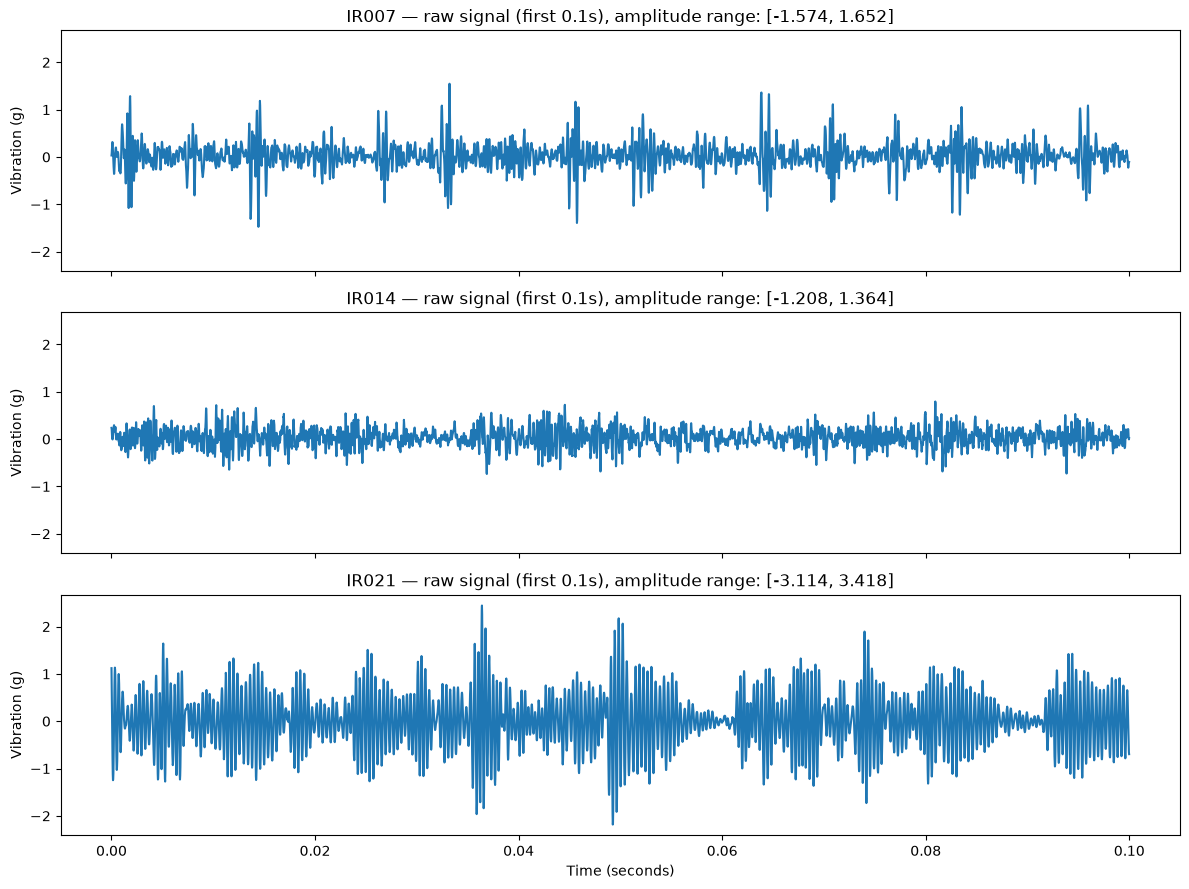

IR007 RMS: 0.2787
IR014 RMS: 0.1979
IR021 RMS: 0.6085


In [25]:
def load_de_signal(filepath):
    signal, rpm = load_mat_file(filepath)
    return signal, rpm

sig_007, rpm_007 = load_de_signal("../data/raw/cwru/IR007_1_110.mat")
sig_014, rpm_014 = load_de_signal("../data/raw/cwru/IR014_1_175.mat")
sig_021, rpm_021 = load_de_signal("../data/raw/cwru/IR021_1_214.mat")

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True, sharey=True)
for ax, sig, label in zip(axes, [sig_007, sig_014, sig_021], ["IR007", "IR014", "IR021"]):
    n = int(0.1 * 48000)  # first 0.1 seconds, same zoom as our very first plot
    t = np.arange(n) / 48000
    ax.plot(t, sig[:n])
    ax.set_title(f"{label} — raw signal (first 0.1s), amplitude range: [{sig.min():.3f}, {sig.max():.3f}]")
    ax.set_ylabel("Vibration (g)")
axes[-1].set_xlabel("Time (seconds)")
plt.tight_layout()
plt.show()

print(f"IR007 RMS: {np.sqrt(np.mean(sig_007**2)):.4f}")
print(f"IR014 RMS: {np.sqrt(np.mean(sig_014**2)):.4f}")
print(f"IR021 RMS: {np.sqrt(np.mean(sig_021**2)):.4f}")

In [26]:
from scipy.fft import fft, fftfreq

def find_resonance_band(signal, fs=48000, search_range=(1000, 8000)):
    n = len(signal)
    yf = np.abs(fft(signal))[:n//2] / n
    xf = fftfreq(n, 1/fs)[:n//2]
    mask = (xf > search_range[0]) & (xf < search_range[1])
    peak_freq = xf[mask][np.argmax(yf[mask])]
    return peak_freq

for label, sig in [("IR007", sig_007), ("IR014", sig_014), ("IR021", sig_021)]:
    peak = find_resonance_band(sig)
    print(f"{label}: strongest resonance peak near {peak:.0f} Hz")

IR007: strongest resonance peak near 2580 Hz
IR014: strongest resonance peak near 1070 Hz
IR021: strongest resonance peak near 2586 Hz


In [27]:
def extract_window_features_v3(window, rpm, resonance_peak, fs=48000, band_width=1000):
    freqs = compute_bearing_frequencies(rpm)

    # Adaptive band, centered on THIS FILE's own resonance peak (computed once, passed in)
    low = max(resonance_peak - band_width/2, 100)
    high = min(resonance_peak + band_width/2, fs/2 - 100)
    nyq = fs / 2
    b, a = butter(4, [low/nyq, high/nyq], btype='band')
    filtered = filtfilt(b, a, window)

    envelope = np.abs(hilbert(filtered))
    envelope = envelope - envelope.mean()
    n = len(envelope)
    yf = np.abs(fft(envelope))[:n // 2] / n
    xf = fftfreq(n, 1/fs)[:n // 2]

    rms = np.sqrt(np.mean(window**2))
    features = {}
    for name in ["BPFO", "BPFI", "BSF"]:
        for harmonic in [1, 2, 3]:
            target = freqs[name] * harmonic
            raw_energy = energy_near_frequency(xf, yf, target)
            features[f"{name}_x{harmonic}_ratio"] = raw_energy / (rms + 1e-8)

    features["rms"] = rms
    features["kurtosis"] = pd.Series(window).kurtosis()
    features["resonance_peak"] = resonance_peak  # keep this too - might itself be informative
    return features

def process_file_v3(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)

    # Find THIS FILE's resonance peak ONCE, using the full signal
    resonance_peak = find_resonance_band(signal, fs=48000, search_range=(1000, 8000))

    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features_v3(window, rpm, resonance_peak)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        feats["window_idx"] = i
        rows.append(feats)
    return rows

# Rebuild the full table
all_rows_v3 = []
for f in mat_files:
    all_rows_v3.extend(process_file_v3(f))

bearing_df_v3 = pd.DataFrame(all_rows_v3)
feature_cols_v3 = [c for c in bearing_df_v3.columns if c not in ["fault_type", "severity", "source_file", "window_idx"]]

print(bearing_df_v3.groupby("source_file")["resonance_peak"].first())  # confirm each file got its own real peak

# Full LOFO-CV, same test as before
lofo_results_v3 = []
for held_out_file in bearing_df_v3["source_file"].unique():
    train_lofo = bearing_df_v3[bearing_df_v3["source_file"] != held_out_file]
    test_lofo = bearing_df_v3[bearing_df_v3["source_file"] == held_out_file]
    X_tr, y_tr = train_lofo[feature_cols_v3], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_v3], test_lofo["fault_type"]
    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    lofo_results_v3.append({"held_out_file": held_out_file, "true_fault_type": test_lofo["fault_type"].iloc[0], "accuracy": acc})

lofo_df_v3 = pd.DataFrame(lofo_results_v3)
print(lofo_df_v3)
fault_only_v3 = lofo_df_v3[lofo_df_v3["true_fault_type"] != "Normal"]
print(f"\nMean LOFO accuracy (adaptive resonance): {fault_only_v3['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy (adaptive resonance): {fault_only_v3['accuracy'].min():.3f}")

source_file
B007_1_123.mat           2761.715608
B014_1_190.mat           1059.264866
B021_1_227.mat           2586.634457
IR007_1_110.mat          2580.242851
IR014_1_175.mat          1069.567084
IR021_1_214.mat          2585.627022
OR007_6_1_136.mat        3401.483965
OR014_6_1_202.mat        3370.421666
OR021_6_1_239.mat        2803.111679
Time_Normal_1_098.mat    4263.135380
Name: resonance_peak, dtype: float64
           held_out_file true_fault_type  accuracy
0         B007_1_123.mat               B  0.576271
1         B014_1_190.mat               B  0.000000
2         B021_1_227.mat               B  0.779661
3        IR007_1_110.mat              IR  1.000000
4        IR014_1_175.mat              IR  0.000000
5        IR021_1_214.mat              IR  0.000000
6      OR007_6_1_136.mat              OR  1.000000
7      OR014_6_1_202.mat              OR  0.000000
8      OR021_6_1_239.mat              OR  0.000000
9  Time_Normal_1_098.mat          Normal  0.000000

Mean LOFO accuracy 

In [28]:
def find_best_kurtosis_band(signal, fs=48000, band_width=1000,
                              search_range=(500, 10000), step=250):
    """
    Scan candidate frequency bands, compute the KURTOSIS of each band's envelope,
    return the center frequency of the band with the highest kurtosis —
    i.e. the band where fault impacts show up most sharply, not just loudest.
    """
    nyq = fs / 2
    best_kurtosis = -np.inf
    best_center = None

    centers = np.arange(search_range[0], search_range[1], step)
    results = []

    for center in centers:
        low = max(center - band_width/2, 100)
        high = min(center + band_width/2, nyq - 100)
        if low >= high:
            continue
        try:
            b, a = butter(4, [low/nyq, high/nyq], btype='band')
            filtered = filtfilt(b, a, signal)
            envelope = np.abs(hilbert(filtered))
            k = pd.Series(envelope).kurtosis()
            results.append({"center": center, "kurtosis": k})
            if k > best_kurtosis:
                best_kurtosis = k
                best_center = center
        except Exception:
            continue

    return best_center, best_kurtosis, pd.DataFrame(results)

# Test it on our three IR files first, before rebuilding everything
for label, sig in [("IR007", sig_007), ("IR014", sig_014), ("IR021", sig_021)]:
    center, kurt, _ = find_best_kurtosis_band(sig)
    print(f"{label}: best band center = {center} Hz, kurtosis = {kurt:.2f}")

IR007: best band center = 9500 Hz, kurtosis = 7.62
IR014: best band center = 9750 Hz, kurtosis = 10.85
IR021: best band center = 9750 Hz, kurtosis = 18.26


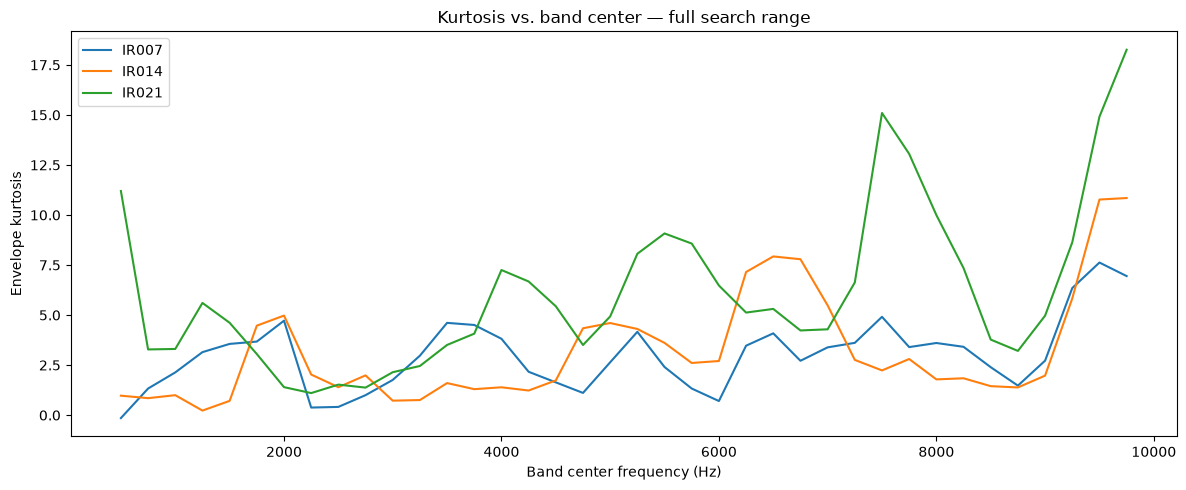

In [29]:
_, _, results_007 = find_best_kurtosis_band(sig_007)
_, _, results_014 = find_best_kurtosis_band(sig_014)
_, _, results_021 = find_best_kurtosis_band(sig_021)

plt.figure(figsize=(12, 5))
plt.plot(results_007["center"], results_007["kurtosis"], label="IR007")
plt.plot(results_014["center"], results_014["kurtosis"], label="IR014")
plt.plot(results_021["center"], results_021["kurtosis"], label="IR021")
plt.xlabel("Band center frequency (Hz)")
plt.ylabel("Envelope kurtosis")
plt.title("Kurtosis vs. band center — full search range")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
from scipy.signal import find_peaks

def find_best_kurtosis_band_v2(signal, fs=48000, band_width=1000,
                                  search_range=(500, 9000), step=250):  # pulled boundary in from 10000 to 9000
    nyq = fs / 2
    centers = np.arange(search_range[0], search_range[1], step)
    kurtosis_values = []

    for center in centers:
        low = max(center - band_width/2, 100)
        high = min(center + band_width/2, nyq - 100)
        if low >= high:
            kurtosis_values.append(-np.inf)
            continue
        try:
            b, a = butter(4, [low/nyq, high/nyq], btype='band')
            filtered = filtfilt(b, a, signal)
            envelope = np.abs(hilbert(filtered))
            kurtosis_values.append(pd.Series(envelope).kurtosis())
        except Exception:
            kurtosis_values.append(-np.inf)

    kurtosis_values = np.array(kurtosis_values)

    # Find genuine LOCAL peaks (rises then falls), not just the highest raw value
    peak_indices, _ = find_peaks(kurtosis_values)
    if len(peak_indices) == 0:
        # fallback: no clear local peak found, use global max as before
        best_idx = np.argmax(kurtosis_values)
    else:
        # pick the tallest genuine local peak
        best_idx = peak_indices[np.argmax(kurtosis_values[peak_indices])]

    return centers[best_idx], kurtosis_values[best_idx], pd.DataFrame({"center": centers, "kurtosis": kurtosis_values})

for label, sig in [("IR007", sig_007), ("IR014", sig_014), ("IR021", sig_021)]:
    center, kurt, _ = find_best_kurtosis_band_v2(sig)
    print(f"{label}: best REAL local peak = {center} Hz, kurtosis = {kurt:.2f}")

IR007: best REAL local peak = 7500 Hz, kurtosis = 4.91
IR014: best REAL local peak = 6500 Hz, kurtosis = 7.93
IR021: best REAL local peak = 7500 Hz, kurtosis = 15.10


In [31]:
def extract_window_features_v4(window, rpm, resonance_peak, fs=48000, band_width=1000):
    freqs = compute_bearing_frequencies(rpm)
    nyq = fs / 2
    low = max(resonance_peak - band_width/2, 100)
    high = min(resonance_peak + band_width/2, nyq - 100)
    b, a = butter(4, [low/nyq, high/nyq], btype='band')
    filtered = filtfilt(b, a, window)

    envelope = np.abs(hilbert(filtered))
    envelope = envelope - envelope.mean()
    n = len(envelope)
    yf = np.abs(fft(envelope))[:n // 2] / n
    xf = fftfreq(n, 1/fs)[:n // 2]

    rms = np.sqrt(np.mean(window**2))
    features = {}
    for name in ["BPFO", "BPFI", "BSF"]:
        for harmonic in [1, 2, 3]:
            target = freqs[name] * harmonic
            raw_energy = energy_near_frequency(xf, yf, target)
            features[f"{name}_x{harmonic}_ratio"] = raw_energy / (rms + 1e-8)

    features["rms"] = rms
    features["kurtosis"] = pd.Series(window).kurtosis()
    features["resonance_peak"] = resonance_peak
    return features

def process_file_v4(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)

    resonance_peak, _, _ = find_best_kurtosis_band_v2(signal)

    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features_v4(window, rpm, resonance_peak)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        feats["window_idx"] = i
        rows.append(feats)
    return rows

all_rows_v4 = []
for f in mat_files:
    all_rows_v4.extend(process_file_v4(f))

bearing_df_v4 = pd.DataFrame(all_rows_v4)
feature_cols_v4 = [c for c in bearing_df_v4.columns if c not in ["fault_type", "severity", "source_file", "window_idx"]]

print(bearing_df_v4.groupby("source_file")["resonance_peak"].first())

lofo_results_v4 = []
for held_out_file in bearing_df_v4["source_file"].unique():
    train_lofo = bearing_df_v4[bearing_df_v4["source_file"] != held_out_file]
    test_lofo = bearing_df_v4[bearing_df_v4["source_file"] == held_out_file]
    X_tr, y_tr = train_lofo[feature_cols_v4], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_v4], test_lofo["fault_type"]
    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    lofo_results_v4.append({"held_out_file": held_out_file, "true_fault_type": test_lofo["fault_type"].iloc[0], "accuracy": acc})

lofo_df_v4 = pd.DataFrame(lofo_results_v4)
print(lofo_df_v4)
fault_only_v4 = lofo_df_v4[lofo_df_v4["true_fault_type"] != "Normal"]
print(f"\nMean LOFO accuracy (kurtosis-based adaptive band): {fault_only_v4['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy: {fault_only_v4['accuracy'].min():.3f}")

source_file
B007_1_123.mat           2500
B014_1_190.mat           1750
B021_1_227.mat           7750
IR007_1_110.mat          7500
IR014_1_175.mat          6500
IR021_1_214.mat          7500
OR007_6_1_136.mat        5250
OR014_6_1_202.mat        5750
OR021_6_1_239.mat        8000
Time_Normal_1_098.mat    3250
Name: resonance_peak, dtype: int64
           held_out_file true_fault_type  accuracy
0         B007_1_123.mat               B  0.050847
1         B014_1_190.mat               B  0.000000
2         B021_1_227.mat               B  0.000000
3        IR007_1_110.mat              IR  0.033898
4        IR014_1_175.mat              IR  0.000000
5        IR021_1_214.mat              IR  0.000000
6      OR007_6_1_136.mat              OR  1.000000
7      OR014_6_1_202.mat              OR  0.000000
8      OR021_6_1_239.mat              OR  0.000000
9  Time_Normal_1_098.mat          Normal  0.000000

Mean LOFO accuracy (kurtosis-based adaptive band): 0.121
Min LOFO accuracy: 0.000


In [32]:
CANDIDATE_BANDS = [1500, 3000, 5000, 7500]  # fixed, same for every file, based on the range we saw real peaks occupy

def extract_window_features_v5(window, rpm, fs=48000, band_width=1000):
    freqs = compute_bearing_frequencies(rpm)
    rms = np.sqrt(np.mean(window**2))
    features = {"rms": rms, "kurtosis": pd.Series(window).kurtosis()}

    for band_center in CANDIDATE_BANDS:
        nyq = fs / 2
        low = max(band_center - band_width/2, 100)
        high = min(band_center + band_width/2, nyq - 100)
        b, a = butter(4, [low/nyq, high/nyq], btype='band')
        filtered = filtfilt(b, a, window)
        envelope = np.abs(hilbert(filtered))
        envelope = envelope - envelope.mean()
        n = len(envelope)
        yf = np.abs(fft(envelope))[:n // 2] / n
        xf = fftfreq(n, 1/fs)[:n // 2]

        for name in ["BPFO", "BPFI", "BSF"]:
            for harmonic in [1, 2]:  # trimmed to 2 harmonics per band to control total feature count (4 bands x 3 x 2 = 24 already)
                target = freqs[name] * harmonic
                raw_energy = energy_near_frequency(xf, yf, target)
                features[f"{name}_x{harmonic}_band{band_center}"] = raw_energy / (rms + 1e-8)

    return features

In [33]:
def process_file_v5(filepath, window_size=8192):
    signal, rpm = load_mat_file(filepath)
    fault_type, severity = parse_label(filepath)
    n_windows = len(signal) // window_size
    rows = []
    for i in range(n_windows):
        window = signal[i*window_size : (i+1)*window_size]
        feats = extract_window_features_v5(window, rpm)
        feats["fault_type"] = fault_type
        feats["severity"] = severity
        feats["source_file"] = os.path.basename(filepath)
        feats["window_idx"] = i
        rows.append(feats)
    return rows

all_rows_v5 = []
for f in mat_files:
    all_rows_v5.extend(process_file_v5(f))

bearing_df_v5 = pd.DataFrame(all_rows_v5)
feature_cols_v5 = [c for c in bearing_df_v5.columns if c not in ["fault_type", "severity", "source_file", "window_idx"]]

print(f"Total features: {len(feature_cols_v5)}")
print(bearing_df_v5.shape)

# Full LOFO-CV, same test as every previous version
lofo_results_v5 = []
for held_out_file in bearing_df_v5["source_file"].unique():
    train_lofo = bearing_df_v5[bearing_df_v5["source_file"] != held_out_file]
    test_lofo = bearing_df_v5[bearing_df_v5["source_file"] == held_out_file]
    X_tr, y_tr = train_lofo[feature_cols_v5], train_lofo["fault_type"]
    X_te, y_te = test_lofo[feature_cols_v5], test_lofo["fault_type"]
    model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    lofo_results_v5.append({"held_out_file": held_out_file, "true_fault_type": test_lofo["fault_type"].iloc[0], "accuracy": acc})

lofo_df_v5 = pd.DataFrame(lofo_results_v5)
print(lofo_df_v5)
fault_only_v5 = lofo_df_v5[lofo_df_v5["true_fault_type"] != "Normal"]
print(f"\nMean LOFO accuracy (fixed multi-band): {fault_only_v5['accuracy'].mean():.3f}")
print(f"Min LOFO accuracy (fixed multi-band): {fault_only_v5['accuracy'].min():.3f}")

# Feature importance - which band(s) actually mattered?
model_final = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
model_final.fit(bearing_df_v5[feature_cols_v5], bearing_df_v5["fault_type"])
importances_v5 = pd.DataFrame({
    "feature": feature_cols_v5,
    "importance": model_final.feature_importances_
}).sort_values("importance", ascending=False)
print("\nTop 15 features:")
print(importances_v5.head(15))

Total features: 26
(590, 30)
           held_out_file true_fault_type  accuracy
0         B007_1_123.mat               B  0.694915
1         B014_1_190.mat               B  0.016949
2         B021_1_227.mat               B  0.627119
3        IR007_1_110.mat              IR  1.000000
4        IR014_1_175.mat              IR  0.000000
5        IR021_1_214.mat              IR  0.000000
6      OR007_6_1_136.mat              OR  1.000000
7      OR014_6_1_202.mat              OR  0.000000
8      OR021_6_1_239.mat              OR  0.000000
9  Time_Normal_1_098.mat          Normal  0.000000

Mean LOFO accuracy (fixed multi-band): 0.371
Min LOFO accuracy (fixed multi-band): 0.000

Top 15 features:
             feature  importance
0                rms    0.099926
9   BPFO_x2_band3000    0.095471
8   BPFO_x1_band3000    0.082938
22  BPFI_x1_band7500    0.075390
16  BPFI_x1_band5000    0.071015
10  BPFI_x1_band3000    0.070035
20  BPFO_x1_band7500    0.063486
4   BPFI_x1_band1500    0.049946
1    